# Exploratory Data Analysis (EDA) — Insurance Claims Data

**Dataset:** `data/raw/MachineLearningRating_v3.txt`  
**Objective:** Understand data, compute basic statistics, assess data quality, and answer key business-questions.

---

## 1. Load the data and initial inspection


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# adjust as needed
RAW_PATH = "../data/raw/MachineLearningRating_v3.txt"

# attempt to load; may need to adjust delimiter / parsing depending on file format
try:
    df = pd.read_csv(RAW_PATH, sep="|", engine="python")
    print("Loaded as pipe-delimited file")
except Exception as e:
    print("CSV load failed:", e)
    try:
        df = pd.read_csv(RAW_PATH, sep=r"\s+", engine="python")
        print("Loaded as whitespace-delimited")
    except Exception as e2:
        print("Whitespace load failed:", e2)
        df = pd.read_fwf(RAW_PATH)
        print("Loaded via fixed-width")

print("Shape:", df.shape)
df.info()
df.head(5)


Loaded as pipe-delimited file
Shape: (1000098, 52)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  object 
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  object 
 5   LegalType                 1000098 non-null  object 
 6   Title                     1000098 non-null  object 
 7   Language                  1000098 non-null  object 
 8   Bank                      854137 non-null   object 
 9   AccountType               959866 non-null   object 
 10  MaritalStatus             991839 non-null   object 
 11  Gender                    990562 non-null   object 
 12  Country                   1000098

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


### Quick observations / notes

- Number of rows / columns (see shape above)  
- Data types per column  
- Does the header look correct? Do columns match expected schema?  
- Do you need to parse dates or convert data types?


## 2. Descriptive Statistics & Data Quality Assessment


In [9]:
# Descriptive statistics for numeric columns
desc = df.describe().T
print(desc)


# Missing values summary
missing = df.isna().sum().sort_values(ascending=False)
missing.head(20)


                              count          mean           std           min  \
UnderwrittenCoverID       1000098.0  1.048175e+05  6.329371e+04  1.000000e+00   
PolicyID                  1000098.0  7.956682e+03  5.290039e+03  1.400000e+01   
PostalCode                1000098.0  3.020601e+03  2.649854e+03  1.000000e+00   
mmcode                     999546.0  5.487770e+07  1.360381e+07  4.041200e+06   
RegistrationYear          1000098.0  2.010225e+03  3.261391e+00  1.987000e+03   
Cylinders                  999546.0  4.046642e+00  2.940201e-01  0.000000e+00   
cubiccapacity              999546.0  2.466743e+03  4.428006e+02  0.000000e+00   
kilowatts                  999546.0  9.720792e+01  1.939326e+01  0.000000e+00   
NumberOfDoors              999546.0  4.019250e+00  4.683144e-01  0.000000e+00   
CustomValueEstimate        220456.0  2.255311e+05  5.645157e+05  2.000000e+04   
NumberOfVehiclesInFleet         0.0           NaN           NaN           NaN   
SumInsured                10

NumberOfVehiclesInFleet    1000098
CrossBorder                 999400
CustomValueEstimate         779642
Rebuilt                     641901
Converted                   641901
WrittenOff                  641901
NewVehicle                  153295
Bank                        145961
AccountType                  40232
Gender                        9536
MaritalStatus                 8259
VehicleType                    552
make                           552
mmcode                         552
Model                          552
Cylinders                      552
bodytype                       552
kilowatts                      552
NumberOfDoors                  552
VehicleIntroDate               552
dtype: int64

## Outlier Detection for Key Numeric Variables


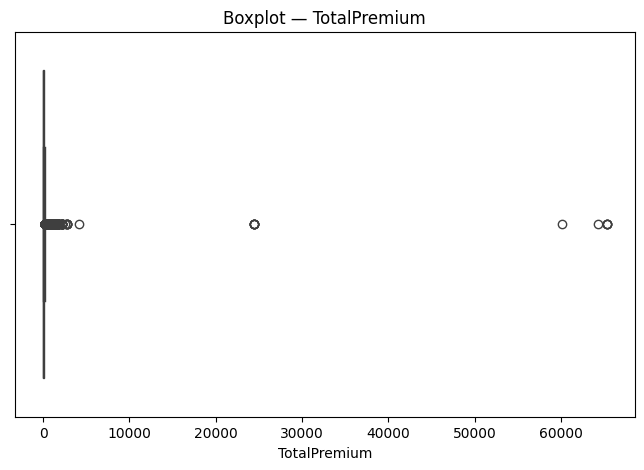

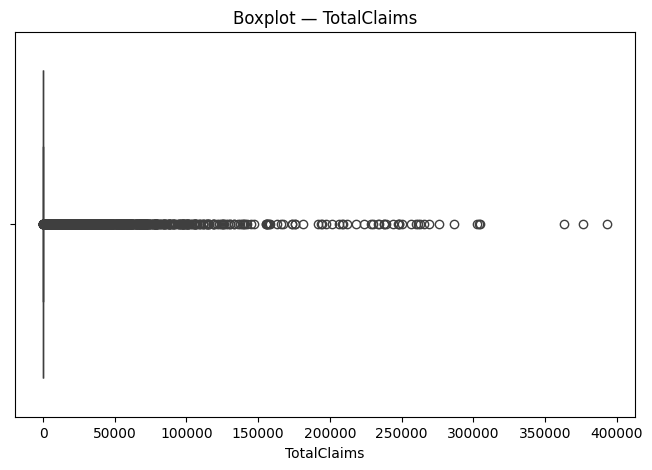

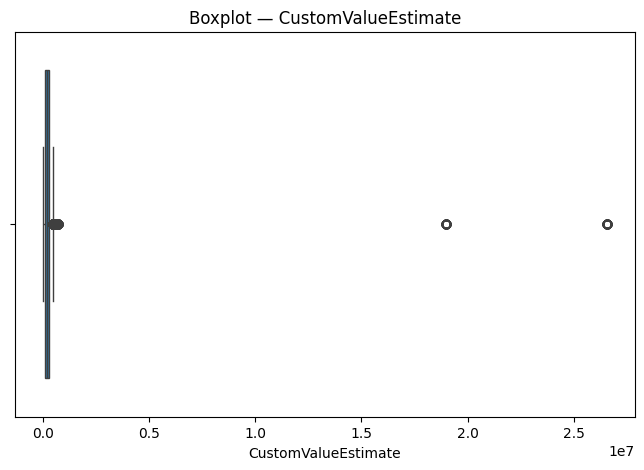

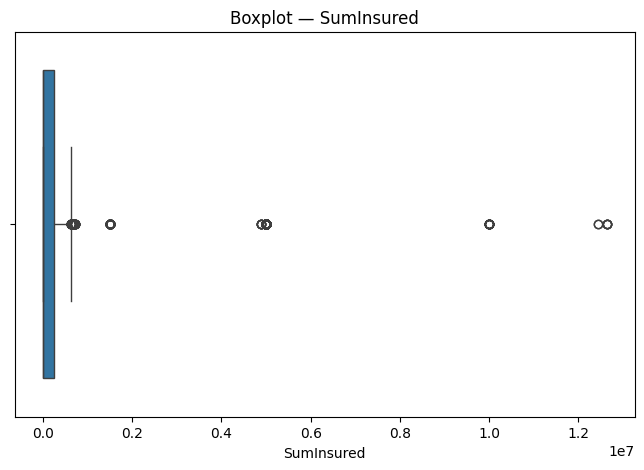

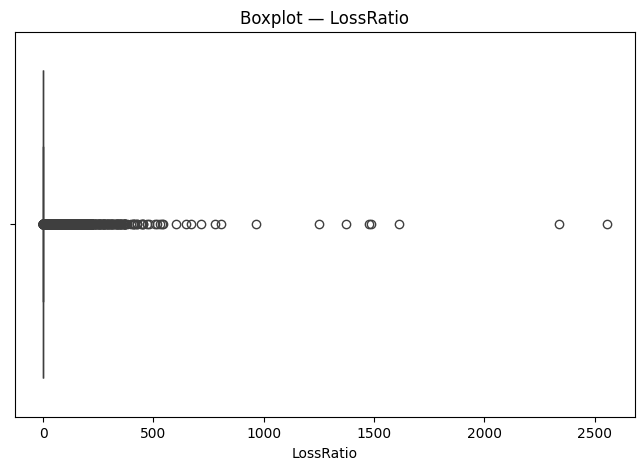

In [10]:
num_cols = ["TotalPremium", "TotalClaims", "CustomValueEstimate", "SumInsured", "LossRatio"]
# 1. Filter out rows where TotalPremium is zero or missing — because ratio cannot be computed
df_valid = df[df["TotalPremium"].notna() & (df["TotalPremium"] > 0)].copy()

# 2. Compute LossRatio, with zero claims → zero
df_valid["LossRatio"] = df_valid["TotalClaims"].fillna(0) / df_valid["TotalPremium"]

# 3. Option: For completeness, also treat negative or absurd TotalClaims or TotalPremium carefully — e.g. drop if claim or premium negative
df_valid = df_valid[(df_valid["TotalPremium"] >= 0) & (df_valid["TotalClaims"] >= 0)]
for col in num_cols:
    if col in df_valid.columns:
        plt.figure(figsize=(8,5))
        sns.boxplot(x=df_valid[col])
        plt.title(f"Boxplot — {col}")
        plt.show()


## Missing Data Pattern — Heatmap Overview


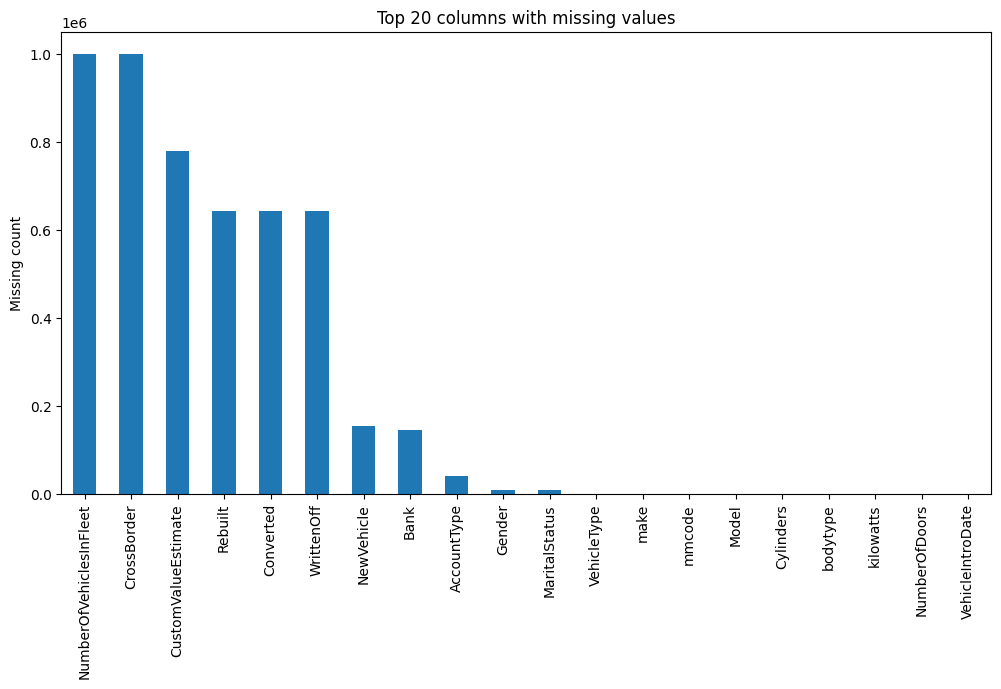

In [11]:
import matplotlib.pyplot as plt

missing_counts = df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
missing_counts.head(20).plot(kind="bar")
plt.title("Top 20 columns with missing values")
plt.ylabel("Missing count")
plt.show()


## 3. Categorical Columns — Unique Counts & Distribution


In [12]:
for col in ["Province", "VehicleType", "Gender", "PostalCode", "Make", "Model"]:
    if col in df.columns:
        print(f"--- {col} ---")
        print("Unique values:", df[col].nunique())
        print(df[col].value_counts(dropna=False).head(15))
        print()


--- Province ---
Unique values: 9
Province
Gauteng          393865
Western Cape     170796
KwaZulu-Natal    169781
North West       143287
Mpumalanga        52718
Eastern Cape      30336
Limpopo           24836
Free State         8099
Northern Cape      6380
Name: count, dtype: int64

--- VehicleType ---
Unique values: 5
VehicleType
Passenger Vehicle    933598
Medium Commercial     53985
Heavy Commercial       7401
Light Commercial       3897
Bus                     665
NaN                     552
Name: count, dtype: int64

--- Gender ---
Unique values: 3
Gender
Not specified    940990
Male              42817
NaN                9536
Female             6755
Name: count, dtype: int64

--- PostalCode ---
Unique values: 888
PostalCode
2000    133498
122      49171
7784     28585
299      25546
7405     18518
458      13775
8000     11794
2196     11048
470      10226
7100     10161
1724     10107
4360      9730
302       9531
152       9423
7750      9408
Name: count, dtype: int64

--- Mod

### Observations & Questions

- How many unique provinces / vehicle types / makes / models / postal codes?  
- Are some categories extremely rare (few observations)? Might need grouping / consolidation.  
- Are there unexpected or misspelled category labels?  


## 4. Compute Business Metric: Loss Ratio & Basic Analysis


In [13]:



# 1. Filter out rows where TotalPremium is zero or missing — because ratio cannot be computed
df_valid = df[df["TotalPremium"].notna() & (df["TotalPremium"] > 0)].copy()

# 2. Compute LossRatio, with zero claims → zero
df_valid["LossRatio"] = df_valid["TotalClaims"].fillna(0) / df_valid["TotalPremium"]

# 3. Option: For completeness, also treat negative or absurd TotalClaims or TotalPremium carefully — e.g. drop if claim or premium negative
df_valid = df_valid[(df_valid["TotalPremium"] >= 0) & (df_valid["TotalClaims"] >= 0)]


# 4. Now df_valid has proper LossRatio values. Use df_valid for analysis.
print("Valid policies (premium>0):", len(df_valid), "/", len(df))
print(df_valid["LossRatio"].describe())



Valid policies (premium>0): 618174 / 1000098
count    618174.000000
mean          0.350095
std           9.288613
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        2553.600000
Name: LossRatio, dtype: float64


### What is the overall Loss Ratio distribution?

Interpret mean, median, min, max, quartiles.  
Are there negative or zero premiums or claims (look for data quality issues)?  


## 5. Univariate & Bivariate Visualizations  


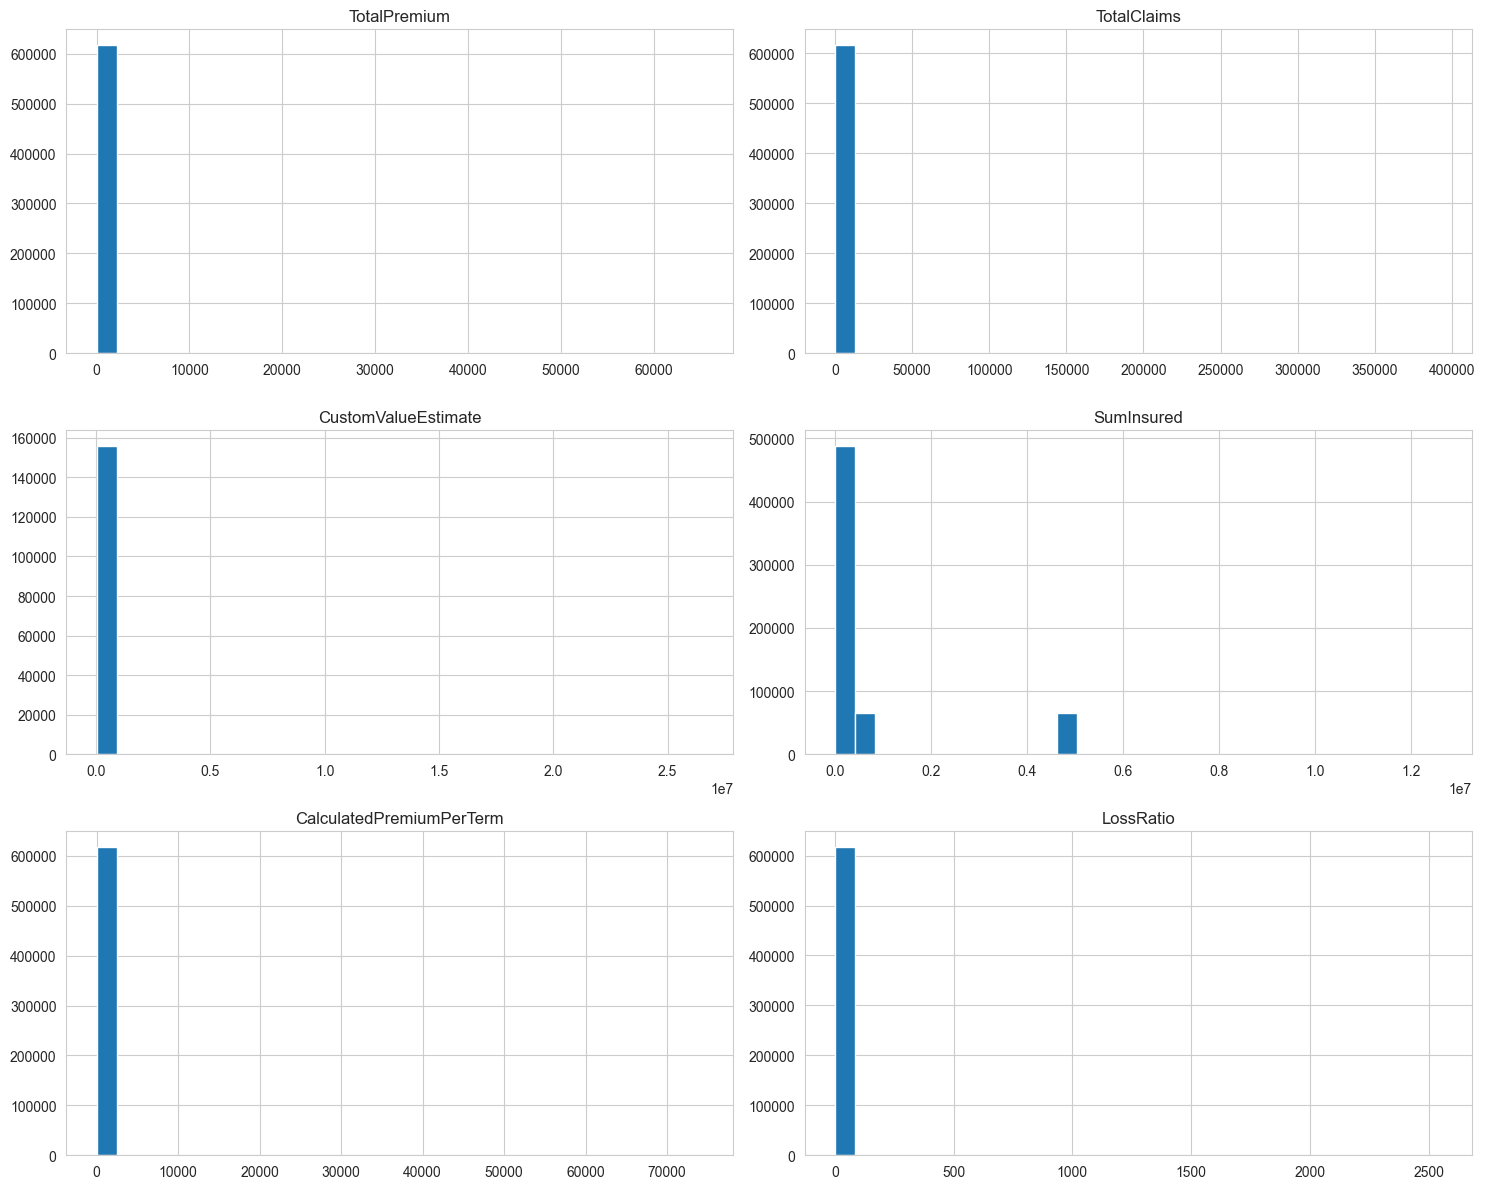

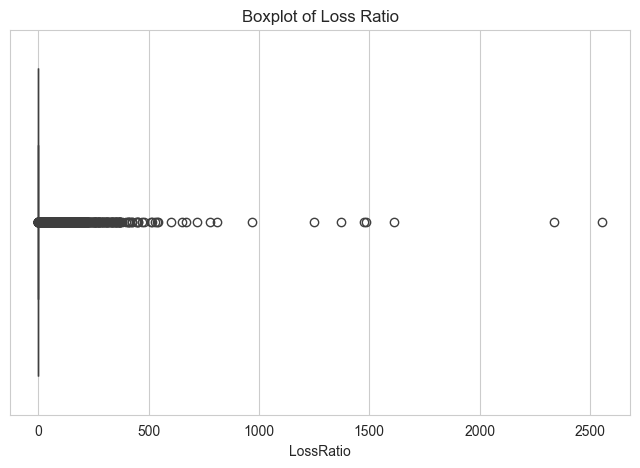

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 5.1 Histograms / distributions for key numeric variables
numeric_vars = [
    "TotalPremium", "TotalClaims", 
    "CustomValueEstimate", 
    "SumInsured", "CalculatedPremiumPerTerm", "LossRatio"
]

df_valid[numeric_vars].hist(bins=30, figsize=(15, 12))
plt.tight_layout()
plt.show()

# 5.2 Boxplot of LossRatio (to detect outliers)
plt.figure(figsize=(8,5))
sns.boxplot(x=df_valid["LossRatio"].dropna())  # drop NaNs for plotting
plt.title("Boxplot of Loss Ratio")
plt.show()


## 6. Segment-level Analysis: Loss Ratio by Province / VehicleType / Gender


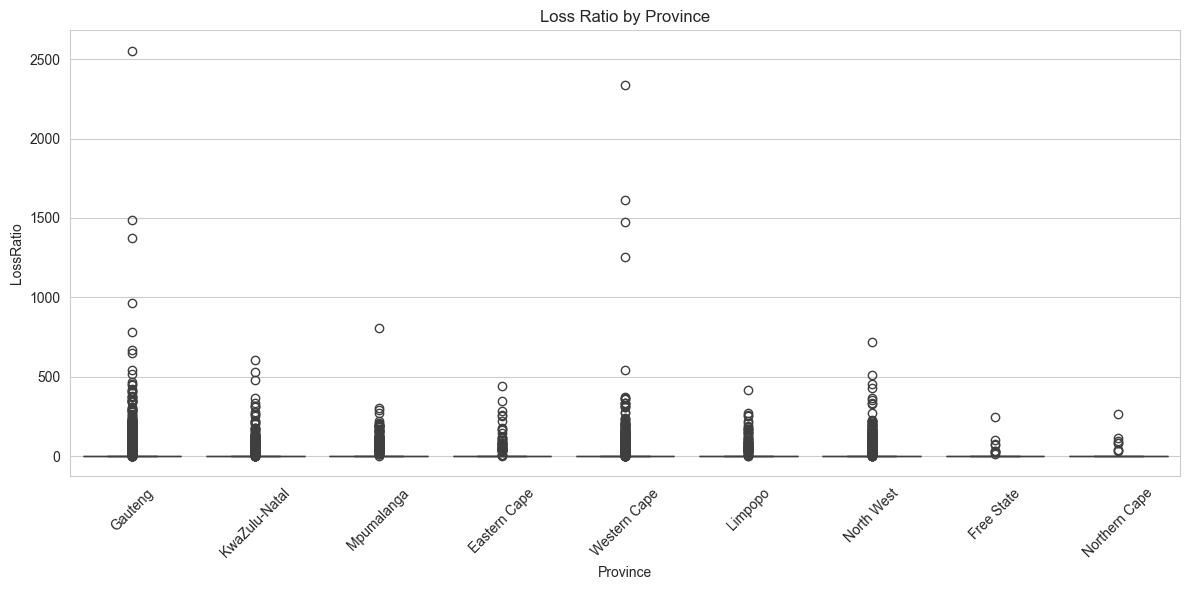

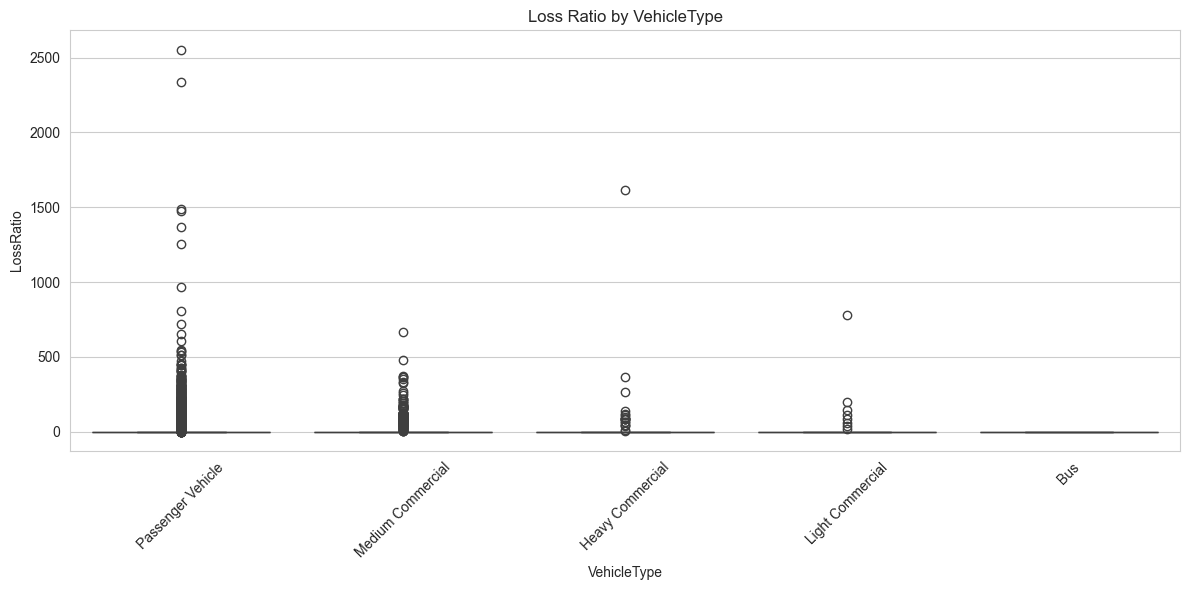

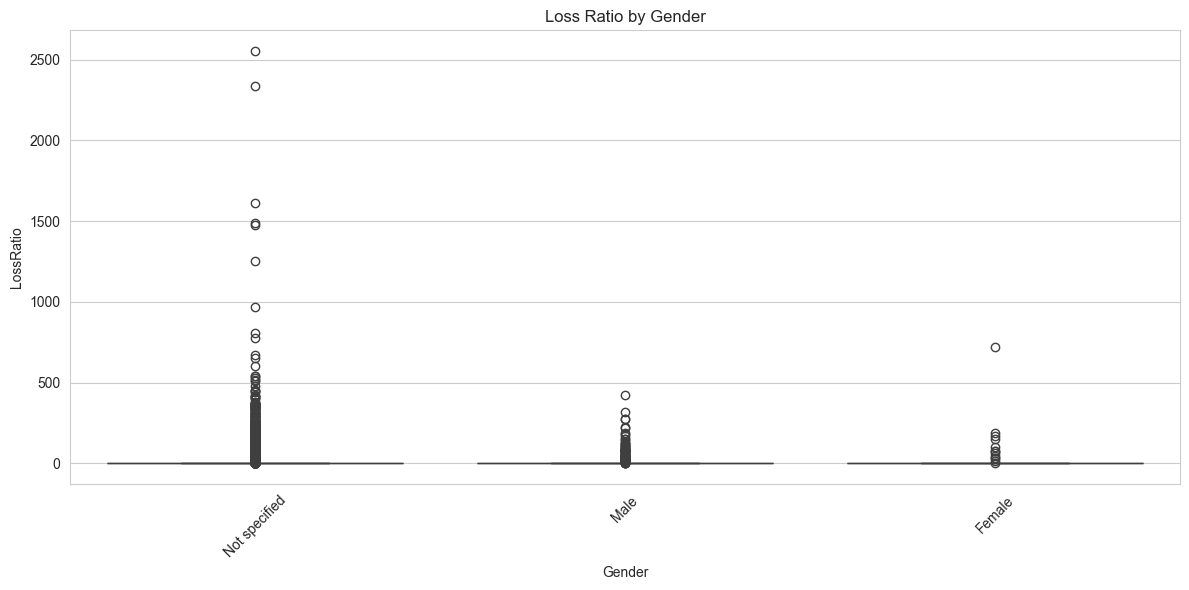

In [15]:
for cat in ["Province", "VehicleType", "Gender"]:
    if cat in df_valid.columns:
        plt.figure(figsize=(12,6))
        sns.boxplot(x=cat, y="LossRatio", data=df_valid)
        plt.title(f"Loss Ratio by {cat}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

### Insights  

- Which provinces appear to have lower / higher median Loss Ratio?  
- Which vehicle types or owner-genders show different risk / loss patterns?  
- Are there outliers or wide variance in some categories — indicating potential sub-segmentation or data quality flags?


## 7. Outlier & Value-Estimate vs Claim Analysis  


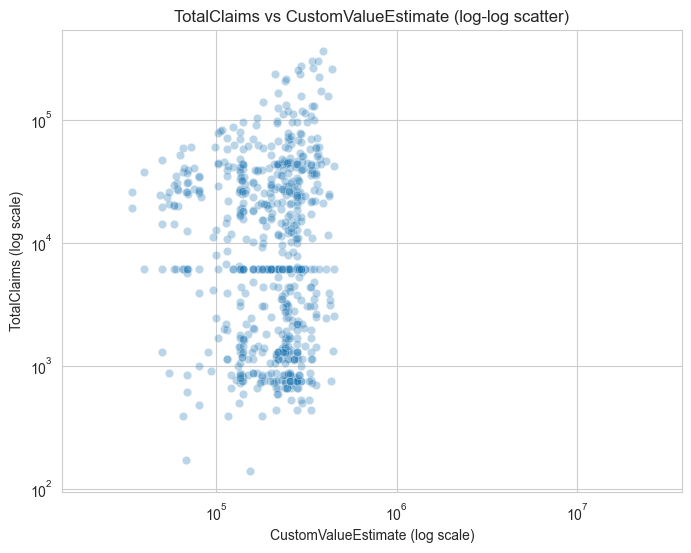

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="CustomValueEstimate", 
    y="TotalClaims", 
    data=df, 
    alpha=0.3
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("CustomValueEstimate (log scale)")
plt.ylabel("TotalClaims (log scale)")
plt.title("TotalClaims vs CustomValueEstimate (log-log scatter)")
plt.show()


### What to look for  

- Are high-value vehicles associated with higher claims (positive correlation)?  
- Are there clusters or outliers — e.g. low-value but high claim, or high-value but zero claims — which might indicate data issues or interesting risk segments.


## 8. Temporal / Time-Series Analysis (if date available)  


C:\Users\azeb.mehrete\AppData\Local\Temp\ipykernel_5788\2195702954.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df_ts.resample("M").agg({


<Figure size 1200x600 with 0 Axes>

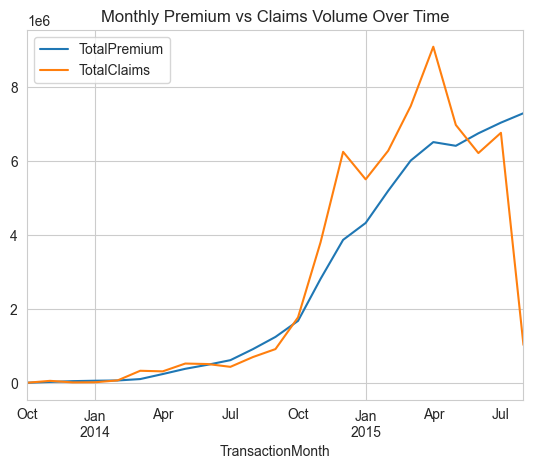

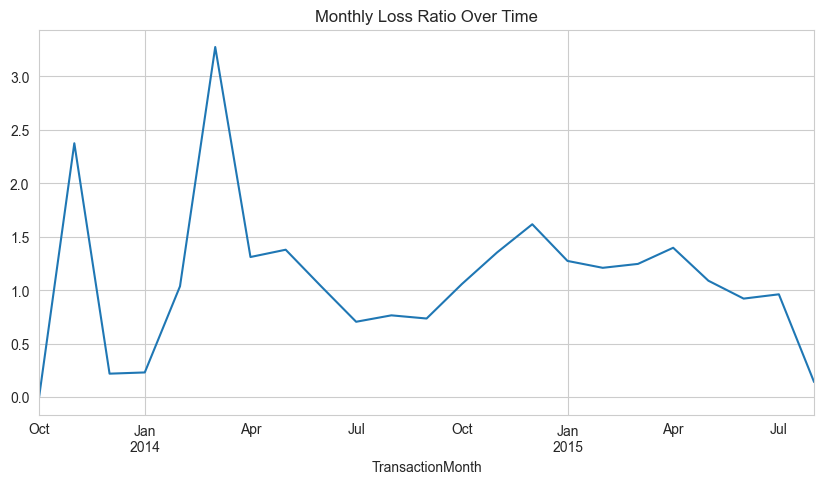

In [17]:
# attempt to parse the month/date column
if "TransactionMonth" in df.columns:
    df["TransactionMonth"] = pd.to_datetime(df["TransactionMonth"], errors="coerce")
    # drop rows where parsing fails (optional)
    df_ts = df.dropna(subset=["TransactionMonth"]).set_index("TransactionMonth")
    
    monthly = df_ts.resample("M").agg({
        "TotalPremium": "sum",
        "TotalClaims": "sum",
        "PolicyID": "count"
    })
    monthly["LossRatio"] = monthly["TotalClaims"] / monthly["TotalPremium"]
    
    plt.figure(figsize=(12,6))
    monthly[["TotalPremium", "TotalClaims"]].plot()
    plt.title("Monthly Premium vs Claims Volume Over Time")
    plt.show()
    
    plt.figure(figsize=(10,5))
    monthly["LossRatio"].plot()
    plt.title("Monthly Loss Ratio Over Time")
    plt.show()
else:
    print("No TransactionMonth column found — skip time-series analysis")


### Observations  

- Over the 18-month period: do premiums / claims increase, decrease, or stay stable?  
- Does loss ratio trend upward or downward, or fluctuate?  
- Are there seasonal patterns or anomalies (spikes, dips) that merit further investigation?


## Correlation Matrix & Pairwise Relationships


In [18]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# select numeric columns only
numeric_df = df_valid.select_dtypes(include=[np.number])

# compute correlation matrix
corr = numeric_df.corr()

# display correlation matrix (rounded)
corr.round(2)


,UnderwrittenCoverID,PolicyID,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims,LossRatio
UnderwrittenCoverID,1.00,0.90,-0.03,0.05,0.08,-0.02,0.07,-0.04,-0.03,0.01,NaN,0.00,0.03,0.03,-0.00,-0.01
PolicyID,0.90,1.00,-0.04,0.04,0.08,-0.03,0.07,-0.04,-0.03,0.01,NaN,0.00,0.03,0.03,-0.00,-0.01
PostalCode,-0.03,-0.04,1.00,0.09,0.02,-0.04,-0.11,-0.18,0.07,-0.02,NaN,0.00,0.02,0.02,0.00,-0.00
mmcode,0.05,0.04,0.09,1.00,-0.09,-0.10,0.22,0.06,0.02,-0.00,NaN,-0.01,-0.00,-0.00,-0.00,-0.00
RegistrationYear,0.08,0.08,0.02,-0.09,1.00,-0.03,0.12,0.18,0.08,0.12,NaN,0.00,0.08,0.08,0.01,-0.00
Cylinders,-0.02,-0.03,-0.04,-0.10,-0.03,1.00,0.28,0.31,-0.26,0.01,NaN,0.00,0.01,0.01,0.00,0.00
cubiccapacity,0.07,0.07,-0.11,0.22,0.12,0.28,1.00,0.59,-0.26,0.04,NaN,-0.01,0.04,0.04,-0.00,-0.00
kilowatts,-0.04,-0.04,-0.18,0.06,0.18,0.31,0.59,1.00,-0.10,0.03,NaN,-0.00,0.03,0.04,0.00,0.00
NumberOfDoors,-0.03,-0.03,0.07,0.02,0.08,-0.26,-0.26,-0.10,1.00,-0.06,NaN,0.00,-0.00,-0.00,0.00,0.00
CustomValueEstimate,0.01,0.01,-0.02,-0.00,0.12,0.01,0.04,0.03,-0.06,1.00,NaN,-0.00,0.02,0.02,0.00,-0.00


### Correlation Heatmap
Below is a heatmap showing correlation between all numeric features — useful to identify strongly correlated or redundant variables.


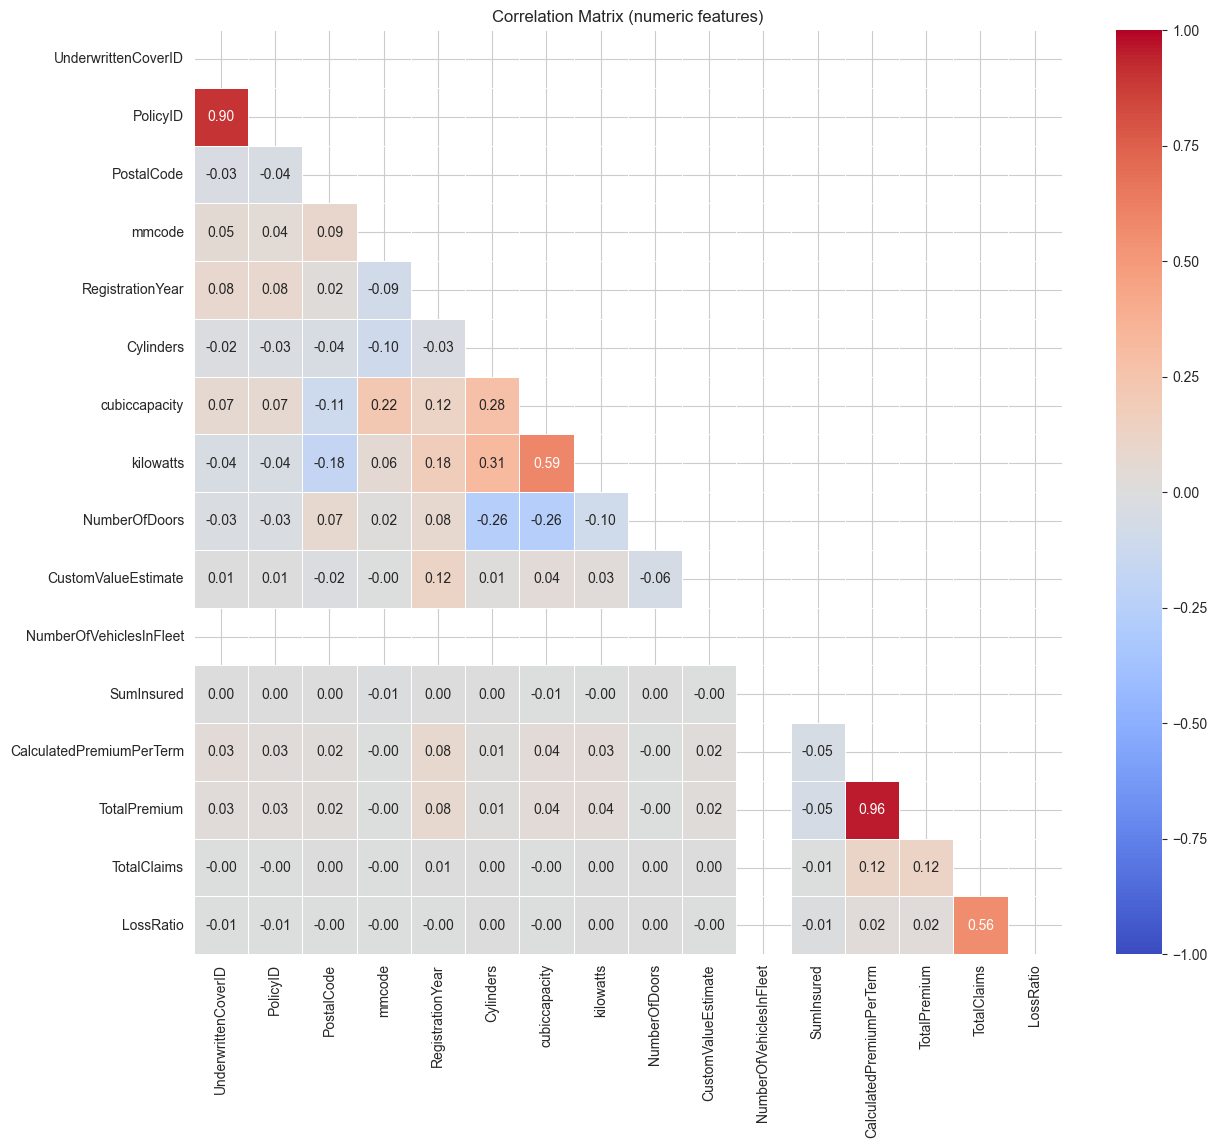

In [19]:
plt.figure(figsize=(14, 12))
# mask upper triangle (optional, makes heatmap cleaner)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix (numeric features)")
plt.show()


### Pairplot (Scatter-matrix) for Selected Numeric Variables
A pairplot helps visualize pairwise relationships (scatter plots + distributions) across numeric variables.


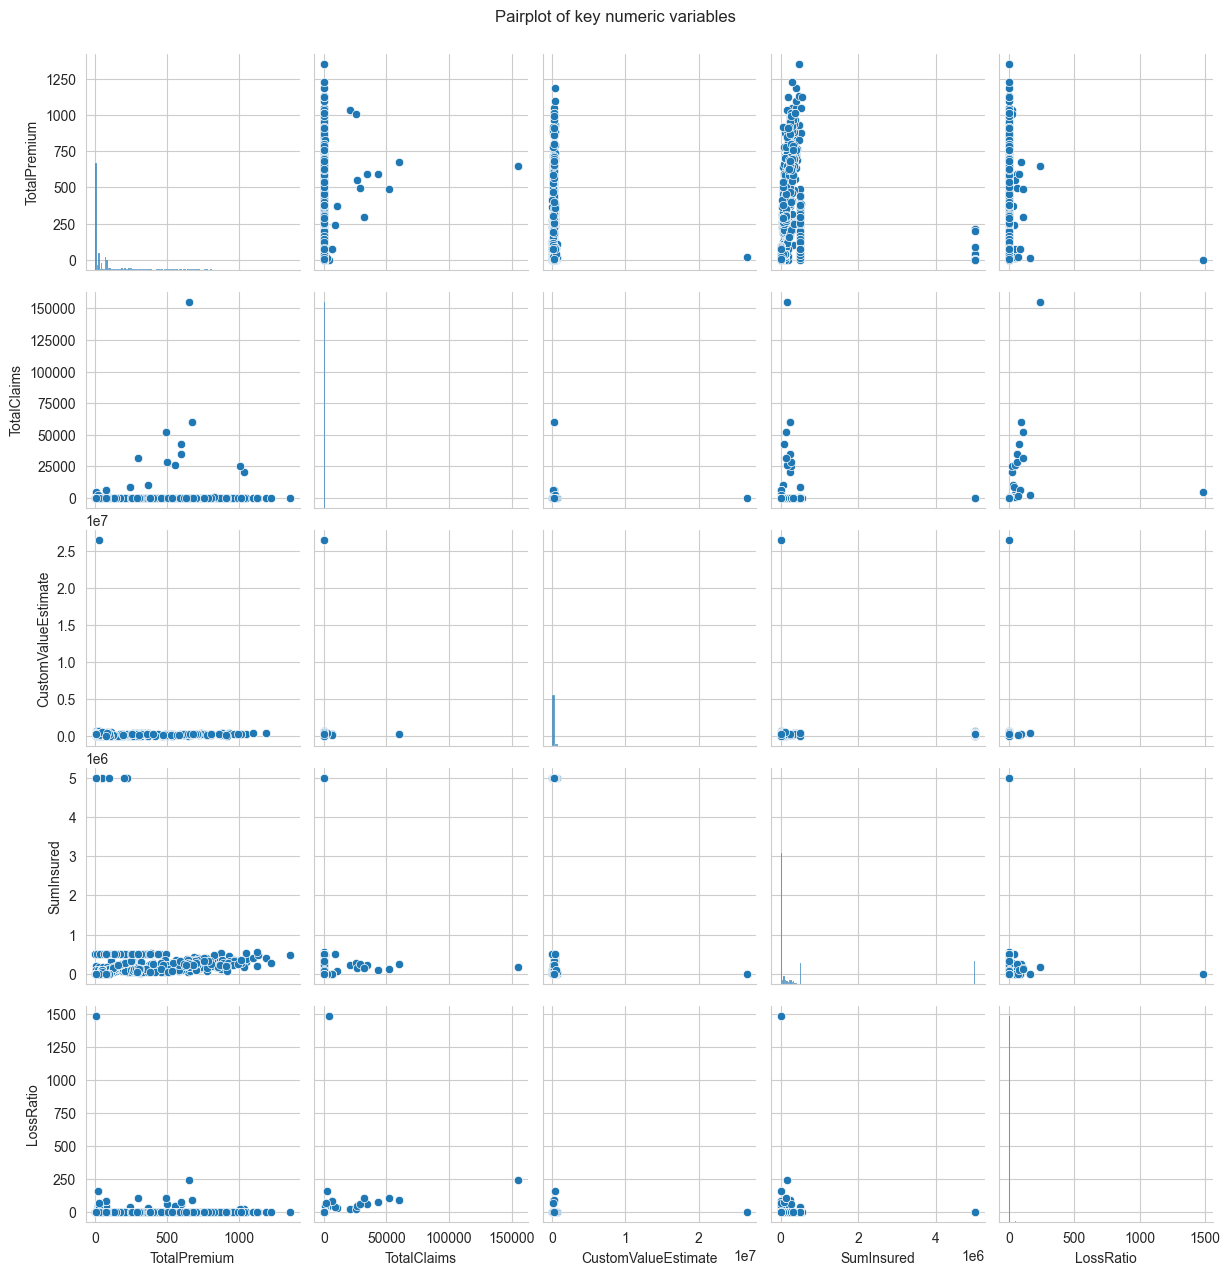

In [20]:
# pick a subset of important numeric columns to avoid too heavy plot
pairs = ["TotalPremium", "TotalClaims", "CustomValueEstimate", "SumInsured", "LossRatio"]
sns.pairplot(df_valid[pairs].sample(min(len(df_valid), 5000)))  # sample if very large
plt.suptitle("Pairplot of key numeric variables", y=1.02)
plt.show()


## Categorical Variable Distributions (Count Plots)


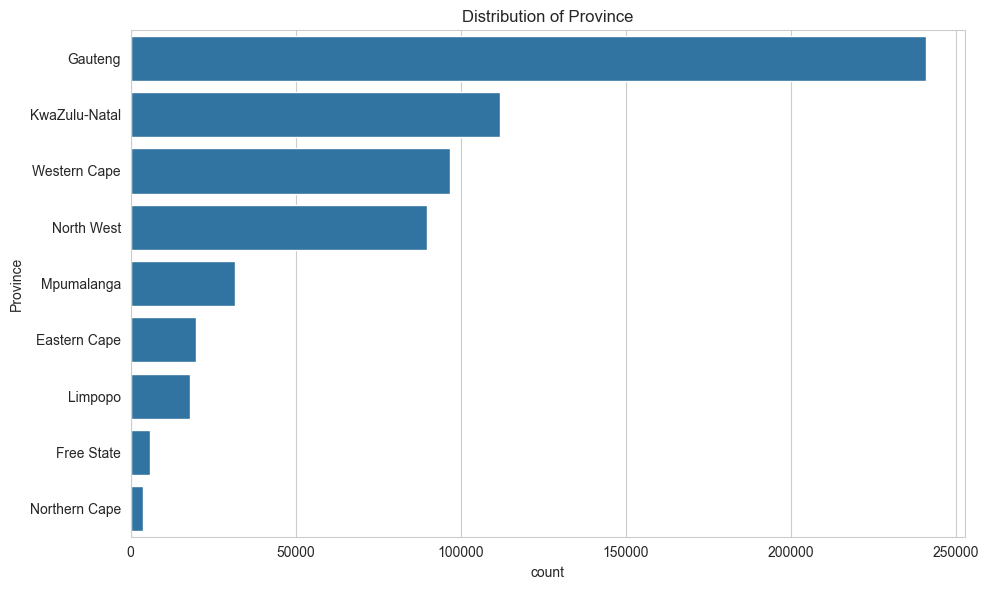

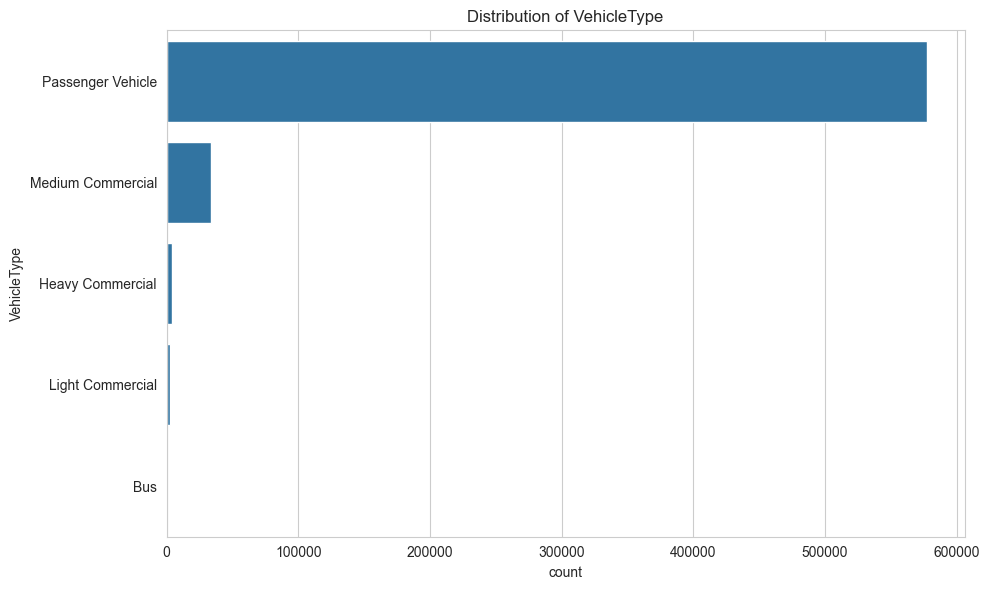

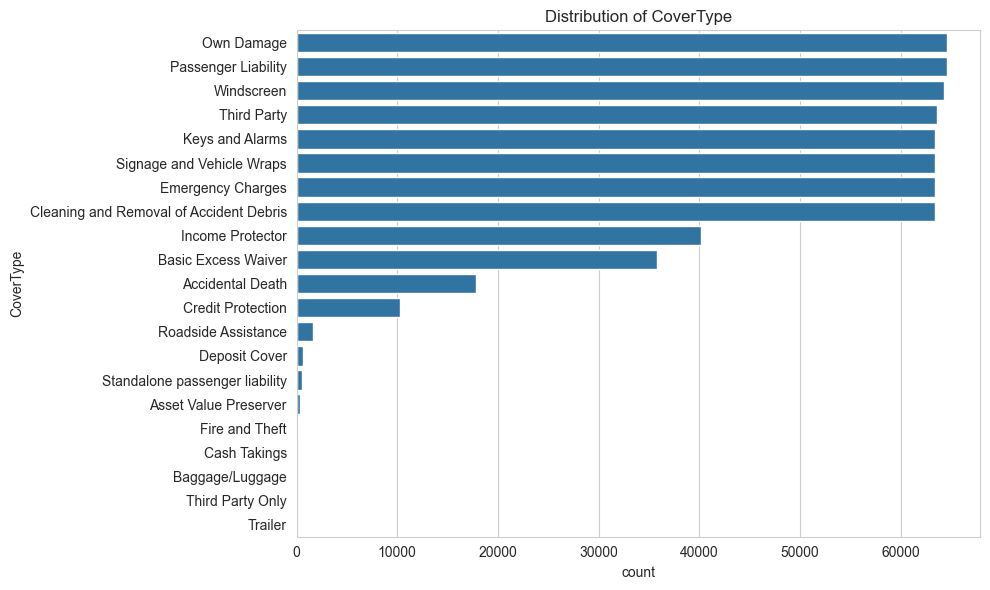

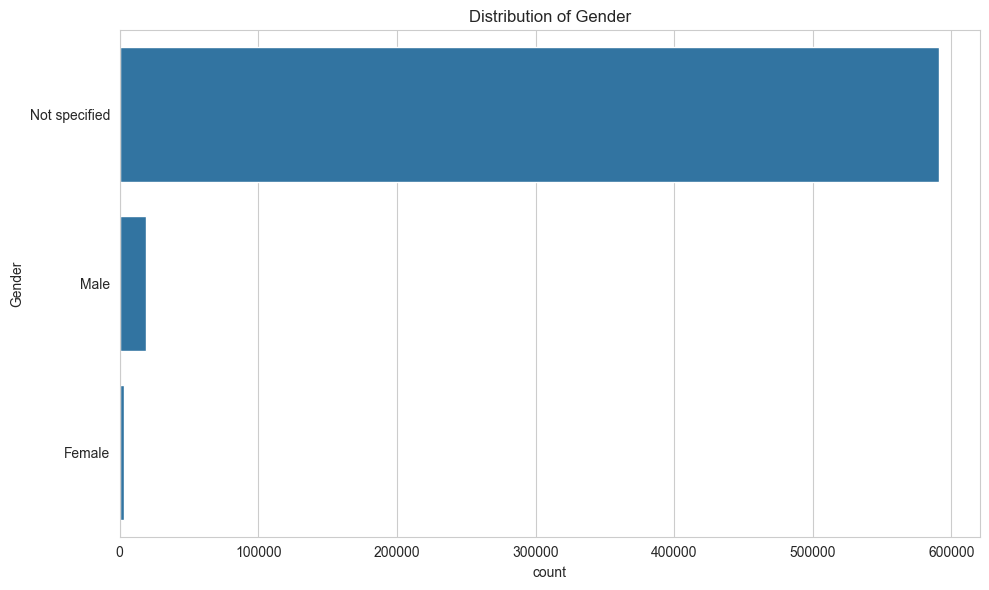

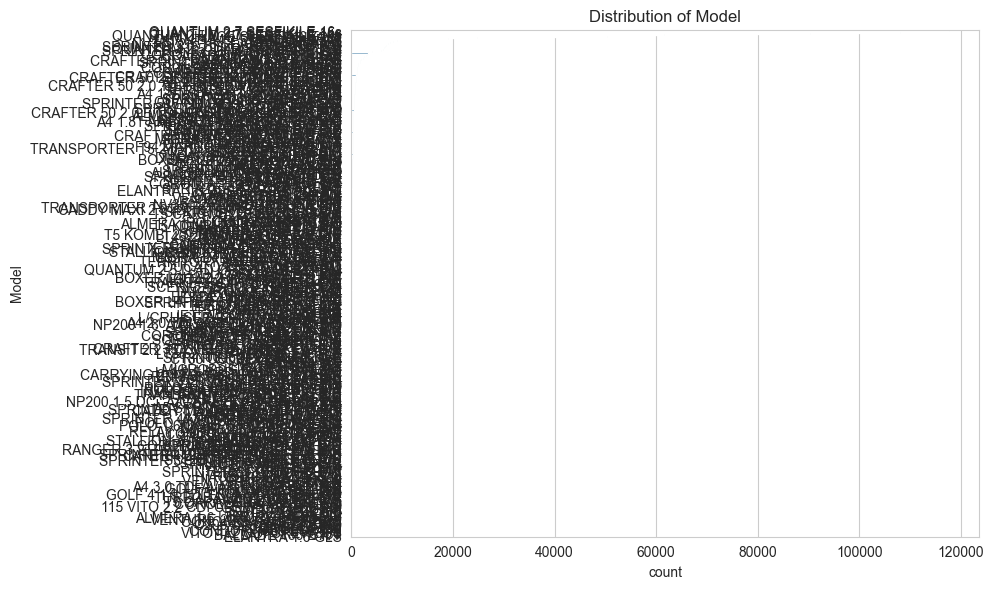

In [21]:
# list of categorical columns you want to examine
cat_cols = ["Province", "VehicleType", "CoverType", "Gender", "Make", "Model"]

for col in cat_cols:
    if col in df_valid.columns:
        plt.figure(figsize=(10,6))
        sns.countplot(y=col, data=df_valid, order=df_valid[col].value_counts().index)
        plt.title(f"Distribution of {col}")
        plt.tight_layout()
        plt.show()


## Segment-level Summary Statistics by Category


In [22]:
# Example: summary by Province
summary_province = df_valid.groupby("Province").agg(
    num_policies = ("PolicyID", "count"),
    num_claims = ("TotalClaims", lambda x: (x>0).sum()),
    claim_rate = ("TotalClaims", lambda x: (x>0).mean()),
    median_loss_ratio = ("LossRatio", "median"),
    mean_loss_ratio = ("LossRatio", "mean"),
    total_premium = ("TotalPremium", "sum"),
    total_claims = ("TotalClaims", "sum")
).reset_index()

summary_province = summary_province.sort_values(by="median_loss_ratio")
summary_province.head(20)


,Province,num_policies,num_claims,claim_rate,median_loss_ratio,mean_loss_ratio,total_premium,total_claims
0,Eastern Cape,19694,47,0.002387,0.0,0.235636,2.140303e+06,1.346308e+06
1,Free State,5932,9,0.001517,0.0,0.106209,5.213632e+05,2.659749e+05
2,Gauteng,240781,1243,0.005162,0.0,0.429006,2.405423e+07,2.799328e+07
3,KwaZulu-Natal,111896,453,0.004048,0.0,0.265328,1.323578e+07,1.352635e+07
4,Limpopo,18009,66,0.003665,0.0,0.348712,1.537324e+06,9.918930e+05
5,Mpumalanga,31663,125,0.003948,0.0,0.392698,2.836292e+06,2.035792e+06
6,North West,89799,334,0.003719,0.0,0.285348,7.490508e+06,5.593723e+06
7,Northern Cape,3643,8,0.002196,0.0,0.203831,3.165581e+05,8.949051e+04
8,Western Cape,96757,356,0.003679,0.0,0.341917,9.809536e+06,1.024795e+07
